# Notebook 01 — Data Cleaning & Integration
## Cardiovascular Care Deserts in Pará, Brazil (2019–2023)

**What this notebook does:**
Takes five raw files from two different sources (DATASUS and IBGE), cleans each one, and combines everything into a single DataFrame ready for clustering analysis.

**Why data cleaning is the most critical step:**
DATASUS and IBGE export files designed for human-readable reports, not machine analysis. This means multi-line headers, footnote rows, missing values represented as `"-"` or `"..."`, and inconsistent text encodings. Skipping this step and running clustering directly will either crash the model or produce meaningless results.

---

## Section 0 — Imports

**What imports are:**
Python alone cannot do statistics, read spreadsheets, or draw maps. The `import` command loads external libraries — packages of code written by others that you use as tools. You install them once; you import them every time you open the notebook.

| Library | Role in this project |
|---|---|
| `pandas` | Read and manipulate tabular data (CSVs) |
| `numpy` | Fast numerical calculations |
| `matplotlib` | Charts and figures |
| `geopandas` | Read shapefiles and render maps |
| `unicodedata` | Normalize text for name matching across sources |
| `os`, `warnings` | System utilities |

In [1]:
# ── SECTION 0 - Data Loading ─────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import os
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


---
## Section 1 — File Paths

**Why centralize paths:**
If you change computers or reorganize folders, you update only this cell — the rest of the notebook keeps working. This pattern is called **separation of configuration and logic**, a basic principle of clean code.

**`raw/`** holds original files — never edited, never overwritten.
**`processed/`** holds files after cleaning.
This separation ensures you can always return to the original data if something goes wrong downstream.

> **Note on relative paths:** This notebook lives in `notebooks/`. The `../` prefix means "go up one level first" — pointing correctly to `data/` at the project root.

In [2]:
# ── SECTION 1 — File Paths ───────────────────────────────────────────────────

PATH_MORTALITY   = '../data/raw/mortalitybycity.csv'
PATH_PROCEDURES  = '../data/raw/proceduresbycity.csv'
PATH_PIB         = '../data/raw/pib.csv'
PATH_POPULATION  = '../data/raw/population.csv'

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('figures', exist_ok=True)

print('✅ Paths defined and output folders created')

✅ Paths defined and output folders created


---
## Section 2 — Mortality Data

**What this file contains:**
Deaths from cardiovascular causes (ICD-10: I20–I25 — angina, acute myocardial infarction, recurrent infarction, ischemic heart disease) by municipality in Pará, from 2019 to 2023.

**Why `skiprows=4`:**
DATASUS places 4 header lines before the actual data — report title, variable type, ICD category, time period. These are not data rows. `skiprows=4` tells pandas to skip lines 0–3 and start reading from line 4.

**Why `encoding='latin-1'`:**
Brazilian government files frequently use the latin-1 encoding standard (ISO-8859-1) instead of UTF-8. Without specifying this, Python cannot interpret characters like `ã`, `ç`, `é` and throws an error.

**Why `sep=';'`:**
CSV stands for *Comma-Separated Values* — but DATASUS uses semicolons as separators, not commas. The `sep=';'` parameter specifies this.

In [3]:
# ── SECTION 2A — Loading Raw Data ────────────────────────────────────────────

# Step 1: Load raw file
mort_raw = pd.read_csv(
    PATH_MORTALITY,
    encoding='latin-1',    # Brazilian character encoding
    sep=';',               # DATASUS uses semicolons, not commas
    skiprows=4,            # Skip 4 DATASUS header lines before data starts
    on_bad_lines='skip'    # Ignore malformed footer lines
)

# Step 2: Rename columns
# DATASUS does not provide clean column names — we define them explicitly
mort_raw.columns = ['municipio', 'mort_2019', 'mort_2020', 'mort_2021',
                    'mort_2022', 'mort_2023', 'mort_total']

print('First rows of raw file:')
mort_raw.head(8)

First rows of raw file:


,municipio,mort_2019,mort_2020,mort_2021,mort_2022,mort_2023,mort_total
0,MUNICIPIO IGNORADO - PA,2,2.0,1.0,3.0,3.0,11.0
1,150010 ABAETETUBA,33,30.0,39.0,60.0,45.0,207.0
2,150013 ABEL FIGUEIREDO,2,2.0,5.0,3.0,2.0,14.0
3,150020 ACARA,16,21.0,21.0,24.0,27.0,109.0
4,150030 AFUA,7,6.0,3.0,2.0,6.0,24.0
5,150034 AGUA AZUL DO NORTE,2,3.0,6.0,4.0,12.0,27.0
6,150040 ALENQUER,27,28.0,37.0,37.0,22.0,151.0
7,150050 ALMEIRIM,9,25.0,11.0,11.0,18.0,74.0


In [4]:
# ── SECTION 2B — Removing Non-Municipality Rows ──────────────────────────────

# Step 3: Remove non-municipality rows
# The file contains footer rows like "Source: Ministry of Health", "Total", "Notes:"
# Real municipality rows always start with a 6-digit IBGE code
# Example: '150010 ABAETETUBA'
mort = mort_raw[mort_raw['municipio'].str.match(r'^\"?\d{6}', na=False)].copy()

# Step 4: Extract IBGE code and municipality name
# The 'municipio' column contains both together: '150010 ABAETETUBA'
# We split them so we can join with other datasets using the code as a key
mort['cod_ibge'] = mort['municipio'].str.extract(r'(\d{6})')
mort['nome_municipio'] = mort['municipio'].str.replace(r'^\d+\s+', '', regex=True).str.strip()
mort['nome_municipio'] = mort['nome_municipio'].str.replace('"', '').str.strip()
mort['cod_ibge'] = mort['cod_ibge'].str.strip()

# Step 5: Ensure numeric columns are actually numeric
# pandas may have read values as strings if the file contained '-' or '...'
# errors='coerce' converts anything that cannot become a number into NaN,
# which we then fill with 0
year_cols = ['mort_2019', 'mort_2020', 'mort_2021', 'mort_2022', 'mort_2023', 'mort_total']
for col in year_cols:
    mort[col] = pd.to_numeric(mort[col], errors='coerce').fillna(0)

# Step 6: Keep only the columns we need
mort = mort[['cod_ibge', 'nome_municipio'] + year_cols]

print(f'✅ Mortality: {len(mort)} municipalities loaded')
print(f'Municipalities with zero deaths across all years: {(mort["mort_total"] == 0).sum()}')
mort.head()

✅ Mortality: 144 municipalities loaded
Municipalities with zero deaths across all years: 0


,cod_ibge,nome_municipio,mort_2019,mort_2020,mort_2021,mort_2022,mort_2023,mort_total
1,150010,ABAETETUBA,33.0,30.0,39.0,60.0,45.0,207.0
2,150013,ABEL FIGUEIREDO,2.0,2.0,5.0,3.0,2.0,14.0
3,150020,ACARA,16.0,21.0,21.0,24.0,27.0,109.0
4,150030,AFUA,7.0,6.0,3.0,2.0,6.0,24.0
5,150034,AGUA AZUL DO NORTE,2.0,3.0,6.0,4.0,12.0,27.0


---
## Section 3 — Procedures Data

**What this file contains:**
Cardiac catheterizations performed through SUS by municipality, 2019–2023. Each row has the municipality, number of approved AIH (Hospital Admission Authorizations), and total SUS expenditure.

**Critical finding:** Only **2 municipalities appear** in this file: Belém and Ananindeua. This is not a download error — it is the actual data. It means the other 142 municipalities in Pará had **zero cardiac catheterization procedures** over the entire study period. This is the central finding of the project.

**What we do:** Load the 2 municipalities with data. In Section 6, the merge will automatically assign zero to the other 142.

In [5]:
# ── SECTION 3 — Data Processing ──────────────────────────────────────────────

proc_raw = pd.read_csv(
    PATH_PROCEDURES,
    encoding='latin-1',
    sep=';',
    skiprows=4,
    on_bad_lines='skip'
)
proc_raw.columns = ['municipio', 'aih_aprovadas', 'valor_total']

# Keep only rows with a valid IBGE code (removes Total, Source, Notes rows)
proc = proc_raw[proc_raw['municipio'].str.match(r'^\"?\d{6}', na=False)].copy()
proc['cod_ibge'] = proc['municipio'].str.extract(r'(\d{6})')

# Brazilian files use comma as decimal separator — convert to float
proc['aih_aprovadas'] = pd.to_numeric(proc['aih_aprovadas'], errors='coerce').fillna(0)
proc['valor_total_reais'] = (proc['valor_total']
                              .astype(str)
                              .str.replace(',', '.')
                              .pipe(pd.to_numeric, errors='coerce')
                              .fillna(0))

proc = proc[['cod_ibge', 'aih_aprovadas', 'valor_total_reais']]

print(f'✅ Procedures: {len(proc)} municipalities with data')
print('Municipalities without procedures will receive zero in the merge')
proc

✅ Procedures: 2 municipalities with data
Municipalities without procedures will receive zero in the merge


,cod_ibge,aih_aprovadas,valor_total_reais
0,150080,64.0,313573.94
1,150140,5260.0,29413499.28


---
## Section 4 — Population Data

**Why we need population:**
Comparing raw death counts between municipalities is unfair — Belém has 1.5 million inhabitants, Melgaço has 25 thousand. The correct approach is to calculate a **rate per 100,000 inhabitants**, which normalizes values and makes municipalities of different sizes comparable.

**Formula:** `rate = (deaths / population) × 100,000`

**Population baseline year: 2021**
The IBGE file provides estimates for 2019, 2020, 2021, and 2024 — years 2022 and 2023 were not available in this export. We use 2021 as the baseline because it is the midpoint of the study period. This is standard practice in epidemiological studies when exact-year data is unavailable.

**Name matching challenge:**
The mortality file has names like `"ABAETETUBA"` (uppercase, no accents).
The population file has names like `"Abaetetuba (PA)"` (mixed case, with accents).
We normalize both sides to the same format before matching.

In [6]:
# ── SECTION 4 — Population Data ──────────────────────────────────────────────

pop = pd.read_csv(
    PATH_POPULATION,
    encoding='utf-8-sig',
    sep=';',
    skiprows=3,          # Skip IBGE title, variable label, and blank rows
    on_bad_lines='skip',
    quotechar='"'
)

# Keep only Pará municipalities — they all contain "(PA)" in the name
pop = pop[pop.iloc[:, 0].str.contains(r'\(PA\)', na=False)].copy()

# Rename columns — confirmed order from file inspection: name, 2019, 2020, 2021, 2024
pop.columns = ['municipio_raw', 'pop_2019', 'pop_2020', 'pop_2021', 'pop_2024']

# Clean numeric columns — remove quotes and thousand-separator dots
for col in ['pop_2019', 'pop_2020', 'pop_2021', 'pop_2024']:
    pop[col] = pd.to_numeric(
        pop[col].astype(str).str.replace('"', '').str.replace('.', '').str.strip(),
        errors='coerce'
    )

# Use 2021 as population baseline (midpoint of 2019–2023 study period)
pop['populacao'] = pop['pop_2021']

# Create normalized name column for matching against mortality file
pop['nome_clean'] = (pop['municipio_raw']
                     .str.replace('"', '')
                     .str.replace(r'\s*\(PA\)', '', regex=True)
                     .str.strip()
                     .str.upper())

print(f'✅ Population: {len(pop)} municipalities loaded')
print(f'   Baseline year: 2021 (midpoint of study period)')
print(f'   Missing values: {pop["populacao"].isna().sum()}')
pop[['municipio_raw', 'populacao']].head()

✅ Population: 144 municipalities loaded
   Baseline year: 2021 (midpoint of study period)
   Missing values: 0


,municipio_raw,populacao
0,Abaetetuba (PA),160439
1,Abel Figueiredo (PA),7536
2,Acará (PA),55744
3,Afuá (PA),39910
4,Água Azul do Norte (PA),27797


---
## Section 5 — GDP Data

**Why GDP per capita:**
GDP per capita is a proxy for average income and economic development. The project hypothesis is that poorer municipalities have less access to cardiac procedures — clustering will test this empirically.

**What we downloaded:** Total gross GDP by municipality (in thousand reais, IBGE standard).
We will calculate GDP per capita by dividing by population in Section 7.

**Why we average across 5 years instead of using a single year:**
GDP in Pará fluctuates significantly year to year due to commodity prices (iron ore, soy, timber dominate the state economy). A 5-year average captures the structural economic level of each municipality rather than a temporary spike or dip.

In [7]:
# ── SECTION 5 — GDP Data ─────────────────────────────────────────────────────

pib = pd.read_csv(
    PATH_PIB,
    encoding='utf-8-sig',
    sep=';',
    skiprows=3,
    on_bad_lines='skip',
    quotechar='"'
)

# Keep only Pará municipalities
pib = pib[pib.iloc[:, 0].str.contains(r'\(PA\)', na=False)].copy()

# Rename — confirmed columns from file inspection: name, 2019, 2020, 2021, 2022, 2023
pib.columns = ['municipio_raw', 'pib_2019', 'pib_2020', 'pib_2021', 'pib_2022', 'pib_2023']

# Clean numeric columns
for col in ['pib_2019', 'pib_2020', 'pib_2021', 'pib_2022', 'pib_2023']:
    pib[col] = pd.to_numeric(
        pib[col].astype(str).str.replace('"', '').str.replace('.', '').str.strip(),
        errors='coerce'
    )

# 5-year average GDP as baseline
pib['pib_medio_mil_reais'] = pib[['pib_2019','pib_2020','pib_2021',
                                    'pib_2022','pib_2023']].mean(axis=1)

# Normalized name for matching
pib['nome_clean'] = (pib['municipio_raw']
                     .str.replace('"', '')
                     .str.replace(r'\s*\(PA\)', '', regex=True)
                     .str.strip()
                     .str.upper())

print(f'✅ GDP: {len(pib)} municipalities loaded')
print(f'   Missing values: {pib["pib_medio_mil_reais"].isna().sum()}')
pib[['municipio_raw', 'pib_medio_mil_reais']].head()

✅ GDP: 144 municipalities loaded
   Missing values: 0


,municipio_raw,pib_medio_mil_reais
0,Abaetetuba (PA),16782442.2
1,Abel Figueiredo (PA),934838.4
2,Acará (PA),11487842.2
3,Afuá (PA),4248176.6
4,Água Azul do Norte (PA),6227411.8


---
## Section 6 — Merge: Joining All Datasets

**What a merge (join) is:**
The operation of combining two tables that share a common column — in this case, `cod_ibge`. It is equivalent to Excel's VLOOKUP, but far more powerful and precise.

**Merge types used here:**
- `left`: keeps all municipalities from the left table even if they have no match in the right table. Municipalities without procedures stay in the dataset and receive NaN (which we fill with 0).
- `inner`: would keep only municipalities present in both tables — we avoid this because it would silently drop municipalities missing from any single source.

**Name normalization strategy:**
The mortality file has both IBGE codes and names. Population and GDP files only have names. We build a lookup dictionary from mortality (name → code), normalize all names to the same format (uppercase, no accents), then transfer codes to the other two files before merging.

**Known mismatch — Eldorado dos Carajás:**
DATASUS registers this municipality as `"ELDORADO DOS CARAJAS"`.
IBGE registers it as `"Eldorado do Carajás"`.
We handle this with a manual override dictionary.

In [8]:
# ── SECTION 6 — Name Normalization + Merged Dataset ──────────────────────────

import unicodedata
def normalize(s):
    """
    Normalize a municipality name for cross-source matching.
    Steps: uppercase → strip accents (NFD decomposition) → collapse spaces.
    Example: 'Acará (PA)' → 'ACARA'
    """
    s = str(s).upper().strip()
    # NFD decomposition separates base letters from accent marks
    # We then drop 'Mn' category characters (non-spacing marks = accents)
    s = ''.join(c for c in unicodedata.normalize('NFD', s)
                if unicodedata.category(c) != 'Mn')
    return ' '.join(s.split())

# Known name mismatches between DATASUS and IBGE
# Add entries here if future data exports introduce new mismatches
manual_overrides = {
    'ELDORADO DO CARAJAS': 'ELDORADO DOS CARAJAS'
}

def normalize_with_override(s):
    n = normalize(s)
    return manual_overrides.get(n, n)

# Build lookup from the mortality file (the only file with both name and IBGE code)
name_to_code = {
    normalize(row['nome_municipio']): row['cod_ibge']
    for _, row in mort.iterrows()
}

# Transfer IBGE codes to population and GDP files via name matching
pop['cod_ibge'] = pop['nome_clean'].apply(
    lambda x: name_to_code.get(normalize_with_override(x), None)
)
pib['cod_ibge'] = pib['nome_clean'].apply(
    lambda x: name_to_code.get(normalize_with_override(x), None)
)

# Report matching results
pop_unmatched = pop[pop['cod_ibge'].isna()]['municipio_raw'].tolist()
pib_unmatched = pib[pib['cod_ibge'].isna()]['municipio_raw'].tolist()

if pop_unmatched:
    print(f'⚠️  Population — {len(pop_unmatched)} unmatched: {pop_unmatched}')
else:
    print('✅ Population — all 144 municipalities matched')

if pib_unmatched:
    print(f'⚠️  GDP — {len(pib_unmatched)} unmatched: {pib_unmatched}')
else:
    print('✅ GDP — all 144 municipalities matched')

# Build merged dataset — mortality as the base (144 municipalities, all with IBGE codes)
df = mort.copy()
df = df.merge(proc[['cod_ibge', 'aih_aprovadas', 'valor_total_reais']], on='cod_ibge', how='left')
df = df.merge(pop[['cod_ibge', 'populacao']], on='cod_ibge', how='left')
df = df.merge(pib[['cod_ibge', 'pib_medio_mil_reais']], on='cod_ibge', how='left')

# Fill missing procedure values with zero
# Absence of a record in the procedures file = zero procedures performed
df['aih_aprovadas']     = df['aih_aprovadas'].fillna(0)
df['valor_total_reais'] = df['valor_total_reais'].fillna(0)

print(f'\n✅ Merged dataset: {len(df)} municipalities, {len(df.columns)} columns')
print(f'   Missing population : {df["populacao"].isna().sum()}')
print(f'   Missing GDP        : {df["pib_medio_mil_reais"].isna().sum()}')
print(f'   With catheterization    : {(df["aih_aprovadas"] > 0).sum()}')
print(f'   Without catheterization : {(df["aih_aprovadas"] == 0).sum()}')

✅ Population — all 144 municipalities matched
✅ GDP — all 144 municipalities matched

✅ Merged dataset: 144 municipalities, 12 columns
   Missing population : 0
   Missing GDP        : 0
   With catheterization    : 2
   Without catheterization : 142


---
## Section 7 — Feature Engineering

**What feature engineering is:**
Creating new variables from existing ones so they are more useful for the model. The clustering algorithm will not receive "deaths in 2019" and "deaths in 2020" as separate inputs — it will receive a standardized rate per 100,000 inhabitants that summarizes the full 5-year period.

**Why rates instead of absolute numbers:**
Belém has 1.5 million people and ~1,000 cardiovascular deaths. Melgaço has 25,000 people and ~10 deaths. In absolute numbers, Belém appears far worse. In rate per 100k: Belém has ~67 deaths/100k, Melgaço has ~40. Without normalization, clustering groups by city size, not by health profile — and health profile is what we are studying.

**GDP per capita:** converts total municipal GDP (in thousand reais) into per-capita income in reais. We multiply by 1,000 to convert from "thousand reais" to "reais" before dividing by population.

**Mortality growth trend:** percentage change from 2019 to 2023. Captures whether cardiovascular mortality is worsening over time. Municipalities with zero deaths in 2019 receive 0 (trend not measurable from a zero baseline).

> **Methodological note on outliers (documented for manuscript):**
> `pib_per_capita` max ≈ R$4.6M — Canaã dos Carajás, home to Vale's S11D iron ore complex. GDP per capita is 22× the state mean. Structurally different from all other municipalities.
> `crescimento_mort` max = 1,100% — small-number problem: 1 death in 2019, 12 in 2023. Mathematically correct, statistically misleading. Flagged, not removed.

In [9]:
# ── SECTION 7 — Data Finalization ────────────────────────────────────────────

# Remove municipalities missing population or GDP (cannot normalize without these)
df = df[df['populacao'].notna() & df['pib_medio_mil_reais'].notna()].copy()
df = df[df['populacao'] > 0]

# Cardiovascular mortality rate per 100,000 inhabitants (full 2019–2023 period)
df['taxa_mort_100k'] = (df['mort_total'] / df['populacao']) * 100_000

# Catheterization procedure rate per 100,000 inhabitants
df['taxa_proc_100k'] = (df['aih_aprovadas'] / df['populacao']) * 100_000

# GDP per capita in reais
# pib_medio_mil_reais is in thousand reais → multiply by 1,000 to convert
df['pib_per_capita'] = (df['pib_medio_mil_reais'] * 1_000) / df['populacao']

# Mortality growth trend: percentage change 2019 → 2023
base = df['mort_2019'].replace(0, np.nan)
df['crescimento_mort'] = ((df['mort_2023'] - df['mort_2019']) / base * 100).fillna(0)

features_cols = ['taxa_mort_100k', 'taxa_proc_100k', 'pib_per_capita', 'crescimento_mort']

print('✅ Features created:')
print(df[features_cols].describe().round(2))
print(f'\nDataset ready for clustering: {len(df)} municipalities')

✅ Features created:
       taxa_mort_100k  taxa_proc_100k  pib_per_capita  crescimento_mort
count          144.00          144.00          144.00            144.00
mean           178.64            2.51       209213.33             58.40
std             74.78           29.11       433375.23            153.26
min             48.72            0.00        51785.58            -80.00
25%            126.09            0.00        90449.07            -23.30
50%            166.92            0.00       124171.73             13.13
75%            224.47            0.00       188712.43             83.33
max            399.68          349.17      4666914.34           1100.00

Dataset ready for clustering: 144 municipalities


---
## Section 8 — Data Quality Diagnostics

**Why run this before modeling:**
Any undetected problem here will contaminate the clustering. Extreme outliers can pull an entire cluster toward a single municipality. Missing values silently drop municipalities from the analysis.

This section also provides the content for the **"Data Quality"** subsection of the manuscript Methods.

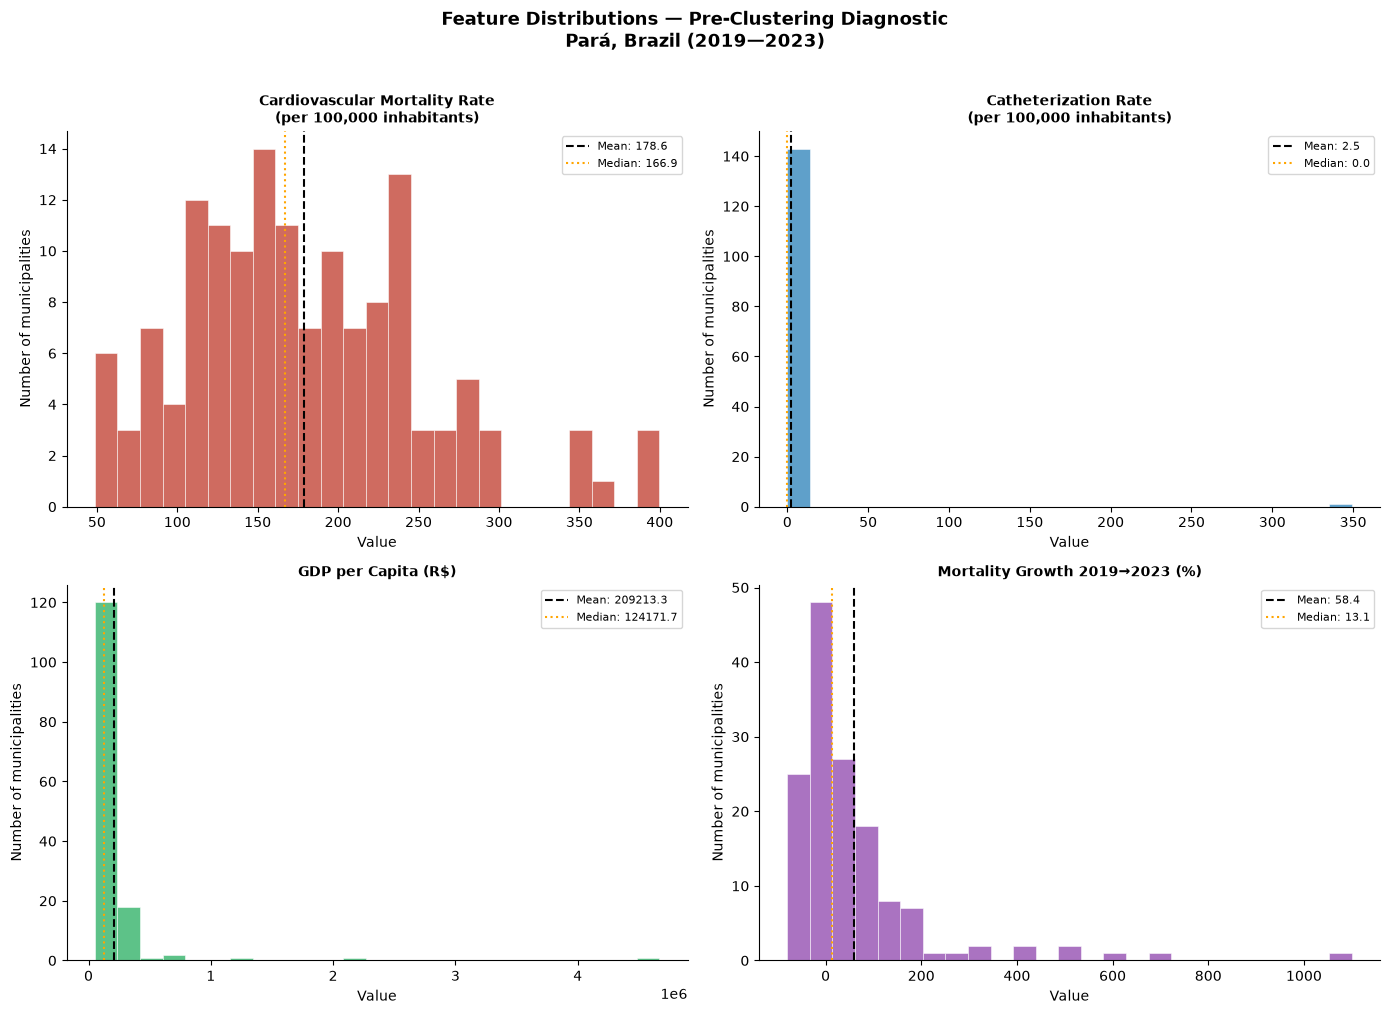

✅ Figure saved: figures/01_feature_distributions.png


In [10]:
# ── SECTION 8A — Feature Distributions — Pre-Clustering Diagnostic ────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distributions — Pre-Clustering Diagnostic\nPará, Brazil (2019—2023)',
             fontsize=13, fontweight='bold', y=1.01)

plot_config = [
    ('taxa_mort_100k',   'Cardiovascular Mortality Rate\n(per 100,000 inhabitants)', '#C0392B'),
    ('taxa_proc_100k',   'Catheterization Rate\n(per 100,000 inhabitants)',           '#2980B9'),
    ('pib_per_capita',   'GDP per Capita (R$)',                                        '#27AE60'),
    ('crescimento_mort', 'Mortality Growth 2019→2023 (%)',                             '#8E44AD'),
]

for ax, (col, title, color) in zip(axes.flat, plot_config):
    ax.hist(df[col].dropna(), bins=25, color=color, alpha=0.75,
            edgecolor='white', linewidth=0.5)
    mean_val   = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val,   color='black',  linestyle='--', linewidth=1.5,
               label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='orange', linestyle=':',  linewidth=1.5,
               label=f'Median: {median_val:.1f}')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Number of municipalities')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/01_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure saved: figures/01_feature_distributions.png')

In [11]:
# ── SECTION 8B — Outlier Detection ───────────────────────────────────────────

# Outlier detection using the IQR method
# IQR = Interquartile Range = Q3 - Q1 (difference between 75th and 25th percentiles)
# Outlier threshold: below Q1 - 1.5×IQR or above Q3 + 1.5×IQR
# This is the standard statistical definition — the same rule used by boxplot whiskers

print('=== OUTLIER REPORT (IQR method) ===')
for col in features_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = df[
        (df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)
    ][['nome_municipio', col]].sort_values(col, ascending=False)
    print(f'\n{col} ({len(outliers)} outliers):')
    print(outliers.to_string(index=False) if len(outliers) else '  None')

=== OUTLIER REPORT (IQR method) ===

taxa_mort_100k (3 outliers):
nome_municipio  taxa_mort_100k
  CURIONOPOLIS      399.684756
       IRITUIA      395.232697
      XINGUARA      391.932359

taxa_proc_100k (2 outliers):
nome_municipio  taxa_proc_100k
         BELEM       349.17221
    ANANINDEUA        11.84286

pib_per_capita (10 outliers):
   nome_municipio  pib_per_capita
CANAA DOS CARAJAS    4.666914e+06
 VITORIA DO XINGU    2.146020e+06
      PARAUAPEBAS    1.296299e+06
     JACAREACANGA    7.605833e+05
     CURIONOPOLIS    7.483776e+05
        BARCARENA    5.383209e+05
          TUCURUI    3.802750e+05
   NOVO PROGRESSO    3.640426e+05
           MARABA    3.446442e+05
        RIO MARIA    3.408504e+05

crescimento_mort (11 outliers):
     nome_municipio  crescimento_mort
  GARRAFAO DO NORTE       1100.000000
        BRASIL NOVO        700.000000
SANTA MARIA DO PARA        600.000000
   MOJUI DOS CAMPOS        500.000000
 AGUA AZUL DO NORTE        500.000000
               MOJU  

---
## Section 9 — Save Final Dataset

**Why save before moving on:**
Each subsequent notebook (`02_eda.ipynb`, `03_clustering.ipynb`) loads this file directly — they do not repeat the cleaning steps. This keeps each notebook focused on one job, and means you can run them independently without re-running everything from scratch.

In [12]:
# ── SECTION 9 — Final Dataset Preparation ────────────────────────────────────

df_final = df[[
    'cod_ibge', 'nome_municipio',
    'mort_2019', 'mort_2020', 'mort_2021', 'mort_2022', 'mort_2023', 'mort_total',
    'aih_aprovadas', 'valor_total_reais',
    'populacao', 'pib_medio_mil_reais',
    'taxa_mort_100k', 'taxa_proc_100k', 'pib_per_capita', 'crescimento_mort'
]].copy()

df_final.to_csv('../data/processed/para_cardiovascular_clean.csv', index=False)
print('✅ Saved: data/processed/para_cardiovascular_clean.csv')

print(f"""
╔══════════════════════════════════════════════════════╗
║           NOTEBOOK 01 — COMPLETE                     ║
╠══════════════════════════════════════════════════════╣
║  Municipalities in dataset : {len(df_final):>3}                     ║
║  Study period              : 2019–2023               ║
║  Total CV deaths           : {int(df_final['mort_total'].sum()):>6}                  ║
║  Total catheterizations    : {int(df_final['aih_aprovadas'].sum()):>6}                  ║
║  Municipalities with cath. : {int((df_final['aih_aprovadas']>0).sum()):>3}                     ║
║  Municipalities without    : {int((df_final['aih_aprovadas']==0).sum()):>3}                     ║
║  Population baseline year  : 2021                    ║
║  GDP baseline              : 5-year average          ║
╚══════════════════════════════════════════════════════╝
Next → 02_eda.ipynb
""")

✅ Saved: data/processed/para_cardiovascular_clean.csv

╔══════════════════════════════════════════════════════╗
║           NOTEBOOK 01 — COMPLETE                     ║
╠══════════════════════════════════════════════════════╣
║  Municipalities in dataset : 144                     ║
║  Study period              : 2019–2023               ║
║  Total CV deaths           :  16677                  ║
║  Total catheterizations    :   5324                  ║
║  Municipalities with cath. :   2                     ║
║  Municipalities without    : 142                     ║
║  Population baseline year  : 2021                    ║
║  GDP baseline              : 5-year average          ║
╚══════════════════════════════════════════════════════╝
Next → 02_eda.ipynb



---
## ✅ Completion Checklist

Before moving to the EDA notebook, confirm:

- [ ] `para_cardiovascular_clean.csv` exists in `data/processed/`
- [ ] Municipality count is 144
- [ ] Exactly 2 municipalities have `aih_aprovadas > 0`
- [ ] `taxa_mort_100k` is calculated with no missing values
- [ ] `pib_per_capita` is in reais (not thousand reais)
- [ ] Zero missing values in population and GDP columns

If any item fails, return to the corresponding section and check column names against the inspection prints.

---
*Next: `02_eda.ipynb` — Exploratory Data Analysis & Visualizations*